# Global Temperature Forecasting

This notebook converts the assignment into a runnable workflow for exploring, decomposing, and forecasting the NASA GISTEMP monthly global temperature anomaly series.

## Goals
- load and prepare the dataset
- explore trend, seasonality, and autocorrelation
- compare naive, ARIMA/SARIMA, and exponential smoothing methods
- evaluate forecasts using MAE, MAPE, and sMAPE
- generate future forecasts with the best-performing model

## 1. Setup and Data Loading

Import the required libraries, define a helper to reshape the NASA data into a monthly time series, and load the global temperature anomaly series.

In [1]:
import os
import warnings
# 1. Suppress at the environment level (catches C-level and pre-init warnings)
os.environ["PYTHONWARNINGS"] = "ignore"

# 2. Global suppression for FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# 3. Targeted regex for those exact messages (just to be absolutely sure)
warnings.filterwarnings("ignore", message=".*force_all_finite.*", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*'M' is deprecated.*", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.arima import ARIMA, AutoARIMA
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.ets import AutoETS
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error

sns.set_theme(style="whitegrid") # Set seaborn theme for better aesthetics
plt.rcParams["figure.figsize"] = (12, 5) # Set default figure size for all plots

url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

def prepare_nasa_data(url):
    raw = pd.read_csv(url, skiprows=1) # Read the CSV file, skipping the first row which contains metadata

    raw = raw.iloc[:, :13].copy() # Keep only the first 13 columns (Year + 12 months)
    raw.columns = [
        "Year", "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
    ]

    raw["Year"] = pd.to_numeric(raw["Year"], errors="coerce")
    raw = raw.dropna(subset=["Year"])
    raw["Year"] = raw["Year"].astype(int)

    df_long = raw.melt(
        id_vars=["Year"],
        var_name="Month",
        value_name="Temperature_Anomaly"
    )

    df_long["Temperature_Anomaly"] = pd.to_numeric(
        df_long["Temperature_Anomaly"].replace("***", np.nan),
        errors="coerce"
    )
    df_long = df_long.dropna(subset=["Temperature_Anomaly"])

    df_long["Date"] = pd.to_datetime(
        df_long["Year"].astype(str) + "-" + df_long["Month"],
        format="%Y-%b"
    )
#   df_long = df_long.sort_values("Date").reset_index(drop=True)
    ts = (
        df_long.sort_values("Date")
        .set_index("Date")["Temperature_Anomaly"]
        .rename("Temperature_Anomaly")
    )
# ts is now a pandas Series with Date as index and Temperature Anomaly as values.
# .rename("Temperature_Anomaly") is used to give the Series a name, which can be helpful for plotting and analysis.

    return ts

ts_data = prepare_nasa_data(url)

print(f"Time series starts at: {ts_data.index.min().date()}")
print(f"Time series ends at:   {ts_data.index.max().date()}")
print(f"Total observations:    {len(ts_data)}")

Time series starts at: 1880-01-01
Time series ends at:   2026-02-01
Total observations:    1754


## 2. Data Cleaning and Time Index Preparation

Inspect the series, confirm data type and missing values, enforce a monthly start frequency, and verify that the series is ready for forecasting.

In [2]:
display(ts_data.head())

print("dtype:", ts_data.dtype)
print("Missing values before frequency alignment:", ts_data.isna().sum())
print("Index monotonic increasing:", ts_data.index.is_monotonic_increasing)

# Use normalized month-end timestamps because sktime's seasonal naive forecaster
# is not compatible with MonthBegin ("MS") frequency in this environment.
ts_data.index = ts_data.index.to_period("M").to_timestamp(how="end").normalize()
ts_data = ts_data.asfreq("ME")

print("Missing values after asfreq:", ts_data.isna().sum())
if ts_data.isna().sum() > 0:  # Check if there are missing values after resampling
    ts_data = ts_data.interpolate(method="time")
    print("Missing values after interpolation:", ts_data.isna().sum())

print("Frequency after preparation:", ts_data.index.freqstr)
print("Ready for forecasting:", ts_data.index.is_monotonic_increasing and ts_data.isna().sum() == 0)

Date
1880-01-01   -0.19
1880-02-01   -0.25
1880-03-01   -0.09
1880-04-01   -0.16
1880-05-01   -0.10
Name: Temperature_Anomaly, dtype: float64

dtype: float64
Missing values before frequency alignment: 0
Index monotonic increasing: True
Missing values after asfreq: 0
Frequency after preparation: ME
Ready for forecasting: True


## 3. Time Series Visualization

Plot the full monthly anomaly series together with a 12-month rolling mean to highlight the long-term warming trend.

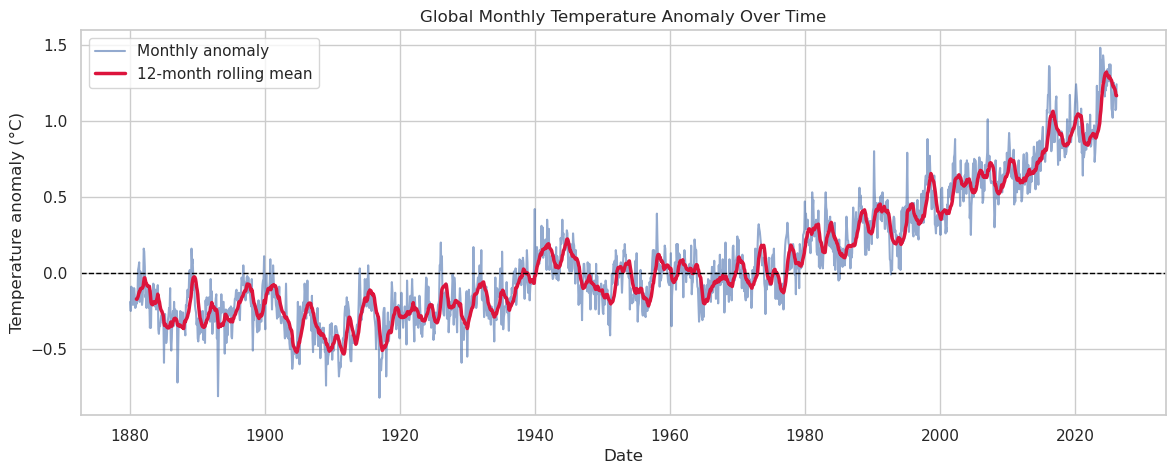

Average anomaly in the first 10 years: -0.214 °C
Average anomaly in the last 10 years:  1.011 °C


In [3]:
rolling_mean_12 = ts_data.rolling(window=12).mean() 
# Calculate the 12-month rolling mean to smooth out short-term fluctuations and highlight longer-term trends in the temperature anomaly data.

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_data.index, ts_data.values, label="Monthly anomaly", alpha=0.6)
ax.plot(rolling_mean_12.index, rolling_mean_12.values, color="crimson", linewidth=2.5, label="12-month rolling mean")
ax.axhline(0, color="black", linestyle="--", linewidth=1)

ax.set_title("Global Monthly Temperature Anomaly Over Time")
ax.set_ylabel("Temperature anomaly (°C)")
ax.set_xlabel("Date")
ax.legend()
plt.show()

early_mean = ts_data.iloc[:120].mean() # Calculate the average anomaly for the first 10 years (120 months) of data
recent_mean = ts_data.iloc[-120:].mean() # Calculate the average anomaly for the last 10 years (120 months) of data

print(f"Average anomaly in the first 10 years: {early_mean:.3f} °C")
print(f"Average anomaly in the last 10 years:  {recent_mean:.3f} °C")

### Interpretation

The chart shows a **clear long-term warming trend** in global temperature anomalies. Early observations are mostly below `0°C`, while recent decades are dominated by **positive anomalies**, especially after around 1980.

Although there is noticeable month-to-month variability, the **12-month rolling mean** rises steadily over time, indicating that the overall increase is not just short-term noise. This suggests that the series contains a strong upward trend, which is important to account for in forecasting models.

## 4. Seasonal Plots and Subseries Analysis

Extract year and month from the index, inspect recent-year seasonal patterns, and compare distributions across calendar months.

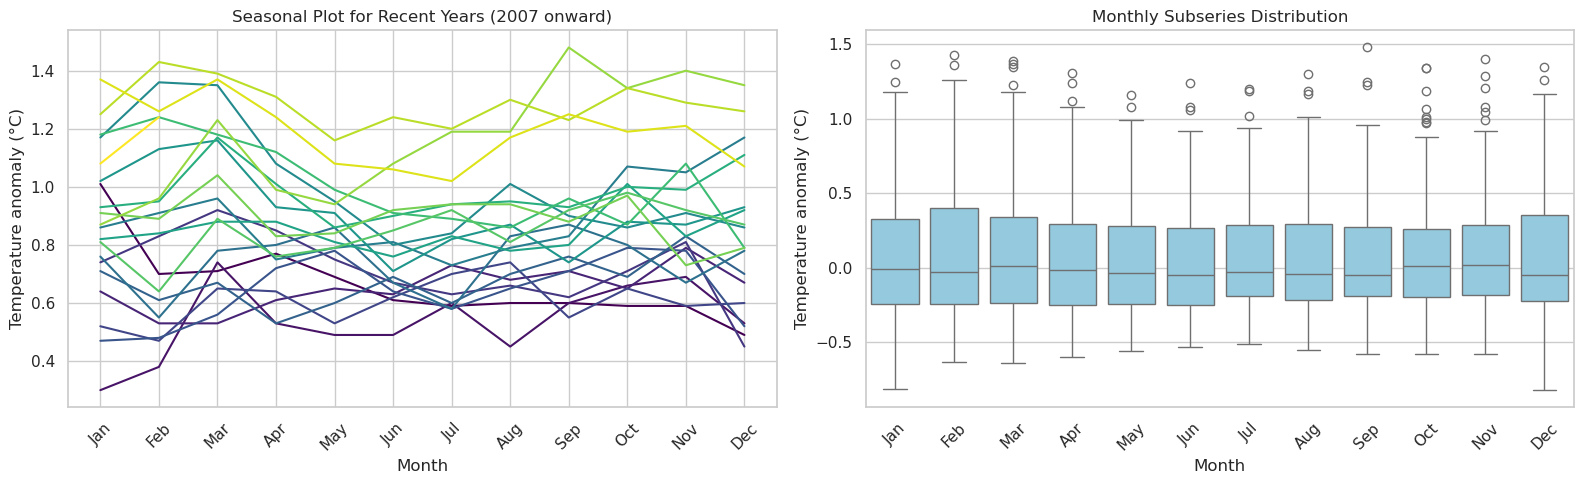

,Average anomaly
Month,
Jan,0.083265
Feb,0.091973
Mar,0.102534
Apr,0.074932
May,0.063219
Jun,0.051370
Jul,0.075411
Aug,0.075479
Sep,0.081438


In [4]:
seasonal_df = ts_data.to_frame(name="Temperature_Anomaly").reset_index()
seasonal_df["Year"] = seasonal_df["Date"].dt.year # Extract year from the Date index for later use in plotting and analysis
seasonal_df["MonthNum"] = seasonal_df["Date"].dt.month # Extract month number for plotting purposes (1-12)
seasonal_df["Month"] = seasonal_df["Date"].dt.strftime("%b") 
# Create a new column with month names (e.g., "Jan", "Feb") for better readability in plots, %b is used to get the abbreviated month name.

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"] 
# Define the order of months for consistent plotting

recent_cutoff = seasonal_df["Year"].max() - 19 # Define cutoff for recent 20 years
recent_df = seasonal_df[seasonal_df["Year"] >= recent_cutoff].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(
    data=recent_df,
    x="MonthNum",
    y="Temperature_Anomaly",
    hue="Year",
    palette="viridis",
    legend=False,
    ax=axes[0]
)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_order, rotation=45)
axes[0].set_title(f"Seasonal Plot for Recent Years ({recent_cutoff} onward)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Temperature anomaly (°C)")

sns.boxplot(
    data=seasonal_df,
    x="Month",
    y="Temperature_Anomaly",
    order=month_order,
    color="skyblue",
    ax=axes[1]
)
axes[1].set_title("Monthly Subseries Distribution")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Temperature anomaly (°C)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

monthly_avg = seasonal_df.groupby("Month")["Temperature_Anomaly"].mean().reindex(month_order)
display(monthly_avg.to_frame("Average anomaly"))

### Interpretation

The seasonal plot suggests that **recent years follow a fairly similar within-year pattern**, but the differences between months are relatively modest compared with the overall upward warming level. This means the dataset shows **some seasonality**, though it is not the dominant feature.

The monthly boxplots also show that the distributions across months overlap substantially, indicating that **trend is stronger than seasonal variation**. In addition, several high outliers in recent years reflect unusually warm months, consistent with the broader rise in global temperature anomalies.

## 5. Autocorrelation Diagnostics

Plot the ACF of the raw series and a first-differenced version to assess persistence and yearly seasonality near lag 12.

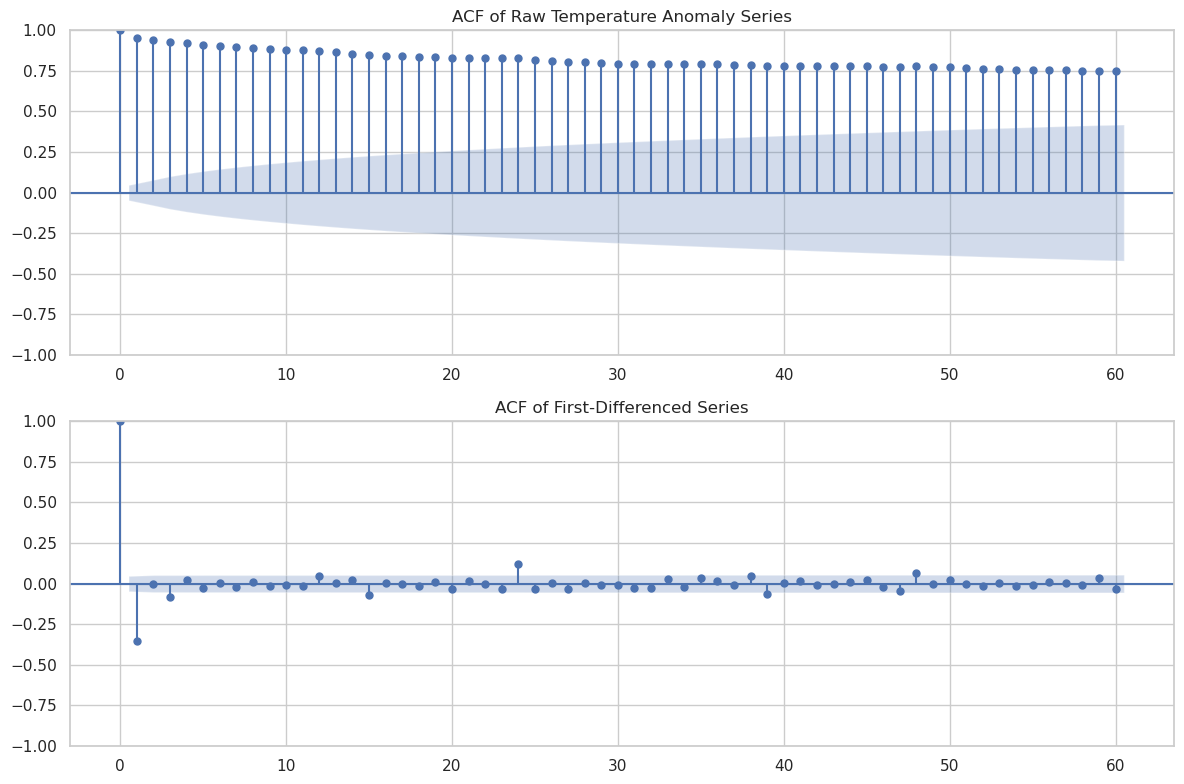

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(ts_data, lags=60, ax=axes[0])
axes[0].set_title("ACF of Raw Temperature Anomaly Series")

plot_acf(ts_data.diff().dropna(), lags=60, ax=axes[1])
axes[1].set_title("ACF of First-Differenced Series")

plt.tight_layout()
plt.show()

### Interpretation

The ACF of the raw series remains **very high and decays slowly** across many lags, which indicates strong persistence and confirms that the original temperature series is **non-stationary**. This is consistent with the long-term upward trend seen earlier.

After first differencing, most autocorrelations fall much closer to zero, suggesting that differencing removes much of the trend and makes the series **more stationary**. This supports using a differencing-based model such as **ARIMA** for forecasting.

## 6. Additive and Multiplicative Decomposition

Decompose the series using an additive model and compare it with a multiplicative decomposition applied to a shifted positive series.

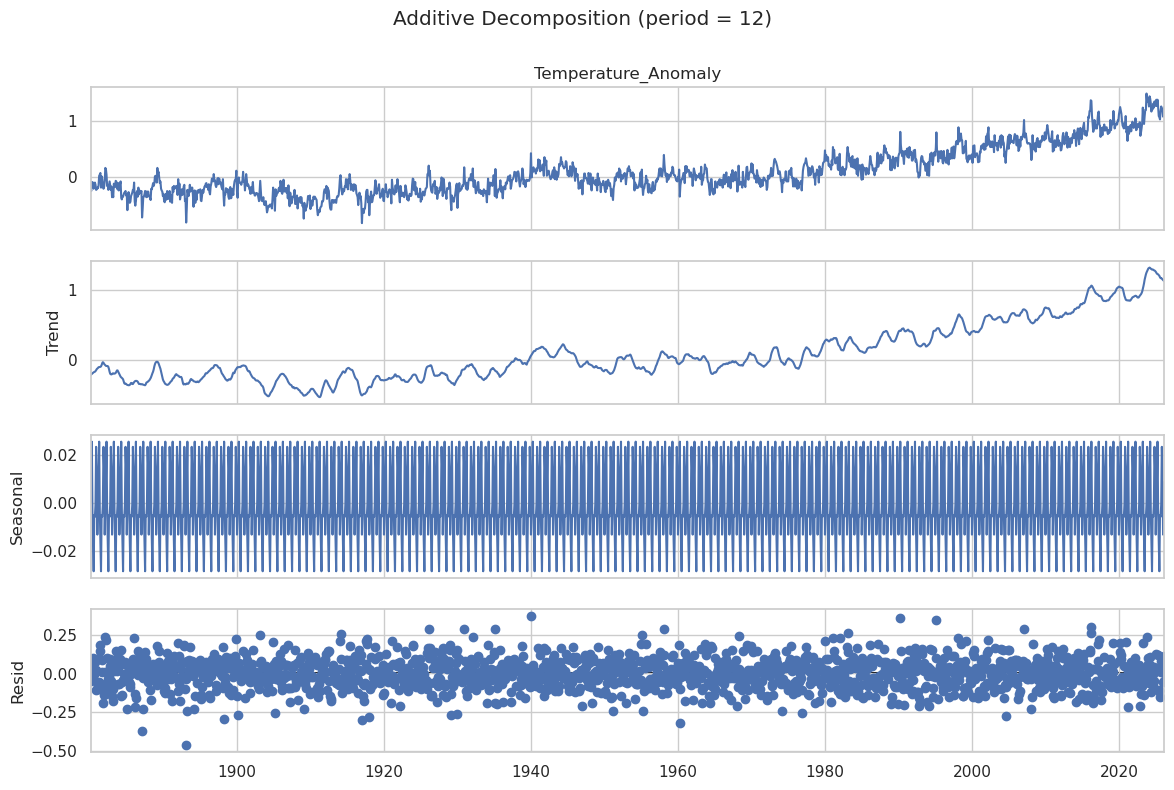

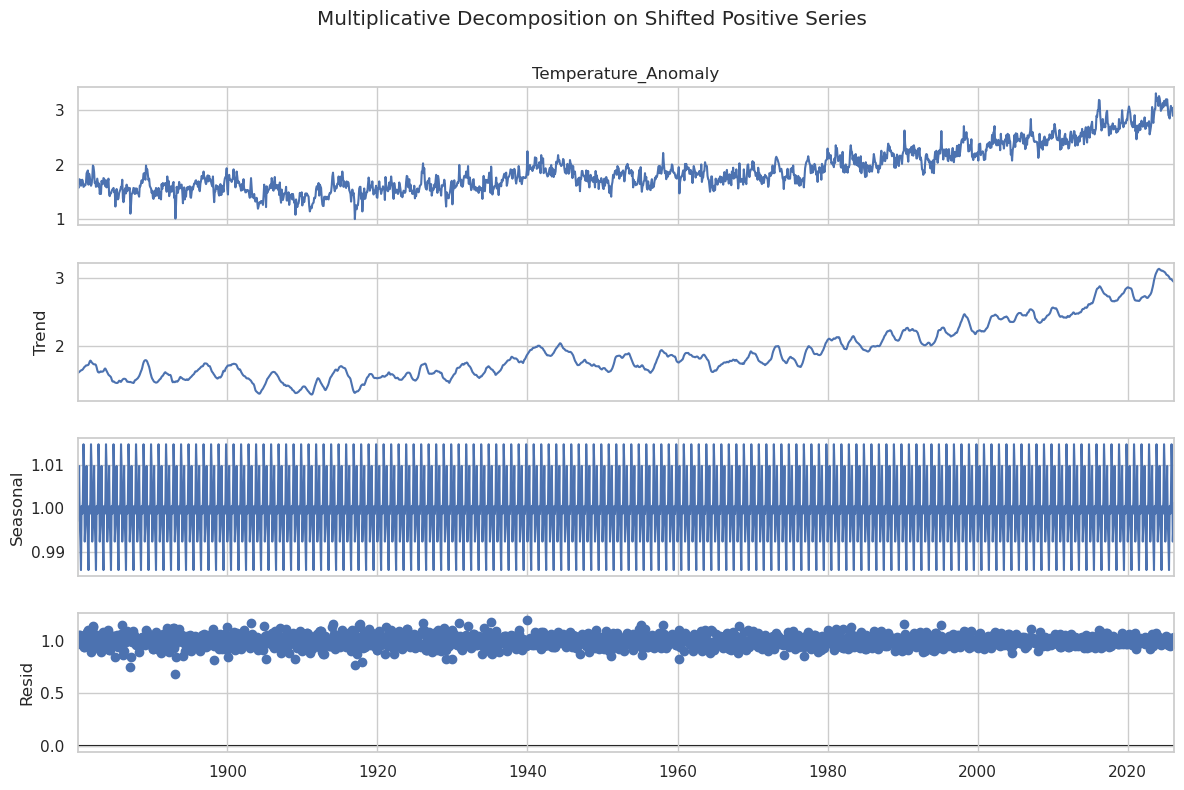

Shift applied to make the series positive for multiplicative decomposition: 1.820


In [6]:
additive_decomp = seasonal_decompose(
    ts_data,
    model="additive",
    period=12,
    extrapolate_trend="freq"
)

shift_value = abs(ts_data.min()) + 1
ts_positive = ts_data + shift_value

multiplicative_decomp = seasonal_decompose(
    ts_positive,
    model="multiplicative",
    period=12,
    extrapolate_trend="freq"
)

fig1 = additive_decomp.plot()
fig1.set_size_inches(12, 8)
fig1.suptitle("Additive Decomposition (period = 12)", y=1.02)
plt.show()

fig2 = multiplicative_decomp.plot()
fig2.set_size_inches(12, 8)
fig2.suptitle("Multiplicative Decomposition on Shifted Positive Series", y=1.02)
plt.show()

print(f"Shift applied to make the series positive for multiplicative decomposition: {shift_value:.3f}")

### Interpretation

Both decomposition plots show that the series is dominated by a **strong upward trend**, especially in the later decades, confirming the continued rise in global temperature anomalies over time.

In the **additive decomposition**, the seasonal component stays relatively small and stable in size, while the residuals are centered near zero with some random variation. This suggests that monthly seasonal effects exist, but they are much weaker than the long-run trend.

In the **multiplicative decomposition**, the seasonal pattern is expressed as a proportion around 1 and also appears fairly stable. Since the seasonal effect does not grow dramatically with the level of the series, the **additive model is generally easier to interpret and likely more appropriate** for this dataset than a multiplicative one.

## 7. Temporal Train/Test Split

Reserve the last 36 months as the test set and define the forecasting horizon for model evaluation.

Training observations: 1718
Testing observations:  36
Train range: 1880-01-31 to 2023-02-28
Test range:  2023-03-31 to 2026-02-28


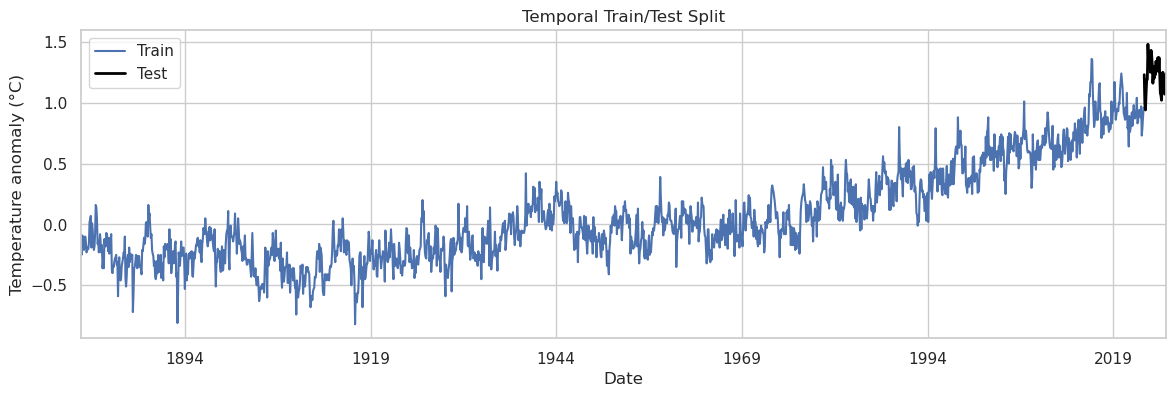

In [7]:
y_train, y_test = temporal_train_test_split(ts_data, test_size=36)
fh = np.arange(1, len(y_test) + 1)

print(f"Training observations: {len(y_train)}")
print(f"Testing observations:  {len(y_test)}")
print(f"Train range: {y_train.index.min().date()} to {y_train.index.max().date()}")
print(f"Test range:  {y_test.index.min().date()} to {y_test.index.max().date()}")

fig, ax = plt.subplots(figsize=(14, 4))
y_train.plot(ax=ax, label="Train")
y_test.plot(ax=ax, label="Test", color="black", linewidth=2)
ax.set_title("Temporal Train/Test Split")
ax.set_ylabel("Temperature anomaly (°C)")
ax.legend()
plt.show()

### Interpretation

This plot shows a **proper temporal split** for forecasting: the earlier observations are used for training, while the most recent 36 months are reserved for testing. This is appropriate for time series data because it preserves the real chronological order and avoids leaking future information into model training.

The test segment lies in the highest part of the series, reflecting the recent warming trend. As a result, forecasting models must be able to capture the **upward trend and recent dynamics** in order to perform well on this holdout period.

## 8. Naive Baseline Forecasts

Fit last-value and seasonal-naive baselines, forecast the test period, and compare the predictions with the actual observations.

/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sktime/forecasting/base/_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sktime/forecasting/base/_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sktime/forecasting/base/_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sktime/forecasting/base/_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)


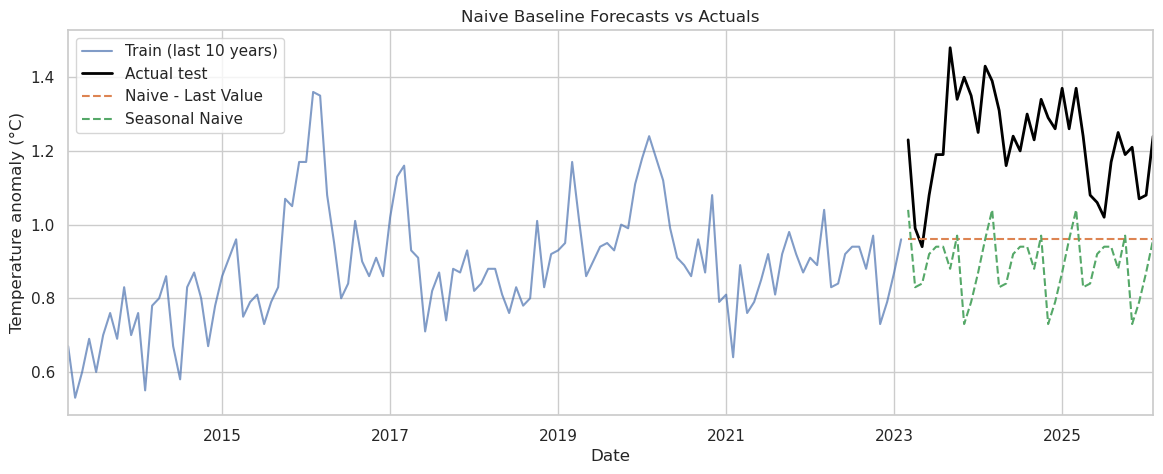

In [8]:
predictions = {}
fitted_models = {}

naive_last = NaiveForecaster(strategy="last")
# Naive forecaster that uses the last observed value as the forecast for all future time points.
# It's imported from sktime and is a simple baseline model for forecasting.

naive_last.fit(y_train)
predictions["Naive - Last Value"] = naive_last.predict(fh)
fitted_models["Naive - Last Value"] = naive_last

seasonal_naive = NaiveForecaster(strategy="last", sp=12)  # Seasonal Naive with seasonal period of 12 months

try:
    seasonal_naive.fit(y_train)
    seasonal_pred = seasonal_naive.predict(fh)

    # Fallback if the library returns missing values for seasonal monthly indices.
    if seasonal_pred.isna().any():
        raise ValueError("Seasonal naive returned NaN values")
except ValueError:
    last_season = y_train.iloc[-12:].to_numpy()
    repeated_pattern = np.tile(last_season, int(np.ceil(len(fh) / 12)))[: len(fh)]
    seasonal_pred = pd.Series(
        repeated_pattern,
        index=y_test.index,
        name="Temperature_Anomaly"
    )

predictions["Naive - Seasonal (sp=12)"] = seasonal_pred
fitted_models["Naive - Seasonal (sp=12)"] = seasonal_naive

fig, ax = plt.subplots(figsize=(14, 5))
y_train.tail(120).plot(ax=ax, label="Train (last 10 years)", alpha=0.7)
y_test.plot(ax=ax, label="Actual test", color="black", linewidth=2)
predictions["Naive - Last Value"].plot(ax=ax, label="Naive - Last Value", linestyle="--")
predictions["Naive - Seasonal (sp=12)"].plot(ax=ax, label="Seasonal Naive", linestyle="--")

ax.set_title("Naive Baseline Forecasts vs Actuals")
ax.set_ylabel("Temperature anomaly (°C)")
ax.legend()
plt.show()

### Interpretation

This plot shows that the **last-value naive forecast** produces a flat line, so it cannot capture the ongoing month-to-month variation or the elevated level seen in the test period. It serves as a simple baseline, but its predictions are clearly too limited for a trending climate series.

The **seasonal naive forecast** attempts to reuse the pattern from the same months in the previous year, which is usually more appropriate for monthly data. However, because the temperature anomalies are also influenced by a strong upward trend, even the seasonal baseline may miss some of the recent increase. This suggests that more flexible models such as **ARIMA or exponential smoothing** may perform better.

## 9. ARIMA and SARIMA Forecasts

Fit a simple ARIMA benchmark and a seasonal AutoARIMA model with yearly seasonality, then visualize their test-set forecasts.

/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sktime/forecasting/base/_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sktime/forecasting/base/_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sktime/forecasting/base/_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sktime/forecasting/bas

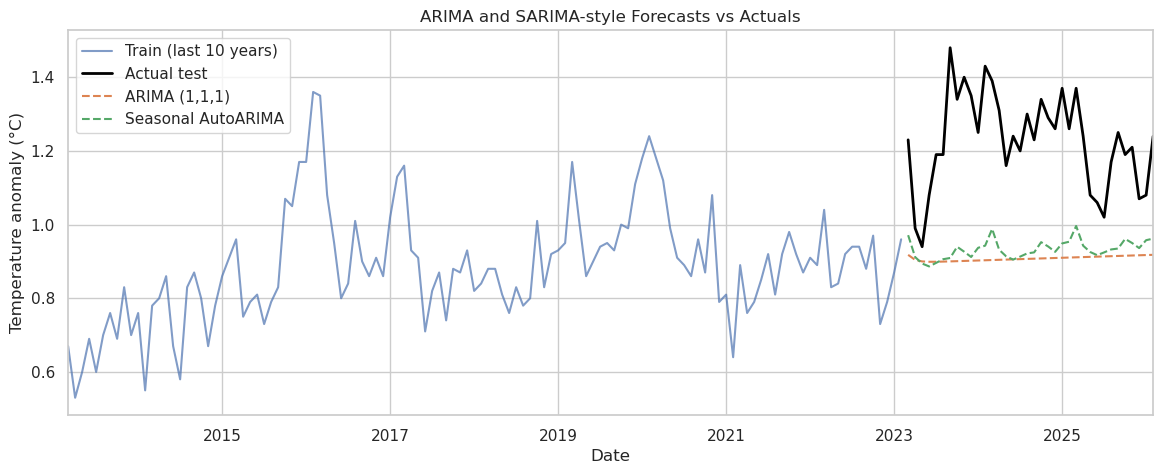

In [9]:
arima_model = ARIMA(order=(1, 1, 1), suppress_warnings=True)
arima_model.fit(y_train)
predictions["ARIMA (1,1,1)"] = arima_model.predict(fh)
fitted_models["ARIMA (1,1,1)"] = arima_model

sarima_model = AutoARIMA(
    sp=12,
    seasonal=True,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    max_p=3,
    max_q=3,
    max_P=2,
    max_Q=2
)
sarima_model.fit(y_train)
predictions["Seasonal AutoARIMA"] = sarima_model.predict(fh)
fitted_models["Seasonal AutoARIMA"] = sarima_model

fig, ax = plt.subplots(figsize=(14, 5))
y_train.tail(120).plot(ax=ax, label="Train (last 10 years)", alpha=0.7)
y_test.plot(ax=ax, label="Actual test", color="black", linewidth=2)
predictions["ARIMA (1,1,1)"].plot(ax=ax, label="ARIMA (1,1,1)", linestyle="--")
predictions["Seasonal AutoARIMA"].plot(ax=ax, label="Seasonal AutoARIMA", linestyle="--")

ax.set_title("ARIMA and SARIMA-style Forecasts vs Actuals")
ax.set_ylabel("Temperature anomaly (°C)")
ax.legend()
plt.show()

### Interpretation

This plot shows that both **ARIMA (1,1,1)** and **Seasonal AutoARIMA** provide more structured forecasts than the naive baselines, but they still tend to **underestimate the high level** of the recent test observations. Their predictions are smoother and remain below many of the actual values, especially during the warmest months.

The **Seasonal AutoARIMA** forecast captures slightly more month-to-month variation than the simpler ARIMA model, suggesting that adding seasonality improves the fit. However, the gap between the forecasts and the actual test series indicates that the recent warming pattern is challenging to model fully, and additional smoothing-based methods may still be competitive.

> Recorded execution time on this laptop for this step: **1 m 53.9 s**.

## 10. Exponential Smoothing and ETS Forecasts

Fit an additive Holt-Winters exponential smoothing model and an ETS model, then forecast the same test horizon.

/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sktime/forecasting/base/_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sktime/forecasting/base/_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sktime/forecasting/base/_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sktime/forecasting/base/_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
/home/fredc/miniconda3/envs/ml/lib/python3.11/si

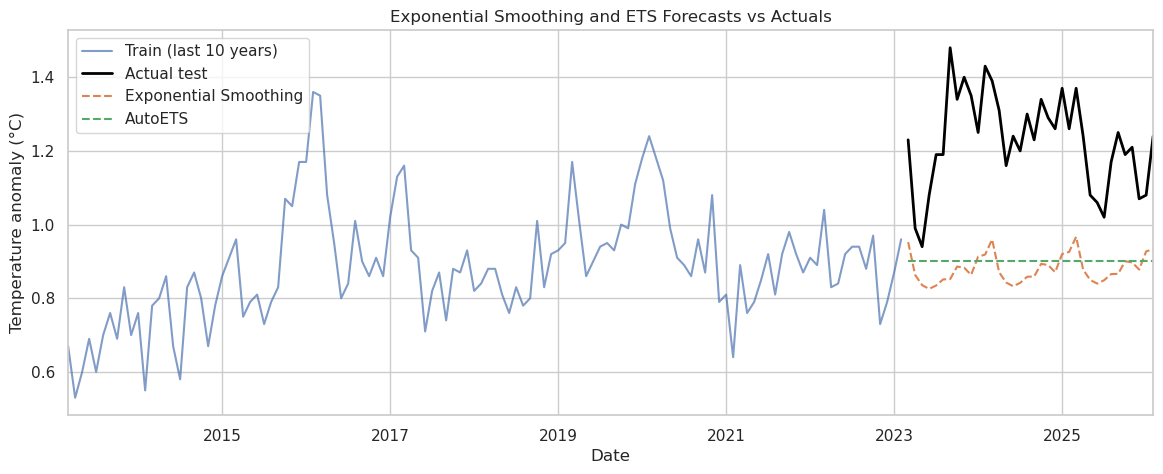

In [10]:
exp_smoothing_model = ExponentialSmoothing(
    trend="add",
    seasonal="add",
    sp=12
)
exp_smoothing_model.fit(y_train)
predictions["Exponential Smoothing"] = exp_smoothing_model.predict(fh)
fitted_models["Exponential Smoothing"] = exp_smoothing_model

try:
    autoets_model = AutoETS(
        auto=True,
        sp=12,
        allow_multiplicative_trend=False,
        restrict=True
    )
    autoets_model.fit(y_train)
except Exception as e:
    print(f"AutoETS auto-search fallback triggered: {e}")
    autoets_model = AutoETS(
        auto=False,
        error="add",
        trend="add",
        seasonal="add",
        damped_trend=True,
        sp=12
    )
    autoets_model.fit(y_train)

predictions["AutoETS"] = autoets_model.predict(fh)
fitted_models["AutoETS"] = autoets_model

fig, ax = plt.subplots(figsize=(14, 5))
y_train.tail(120).plot(ax=ax, label="Train (last 10 years)", alpha=0.7)
y_test.plot(ax=ax, label="Actual test", color="black", linewidth=2)
predictions["Exponential Smoothing"].plot(ax=ax, label="Exponential Smoothing", linestyle="--")
predictions["AutoETS"].plot(ax=ax, label="AutoETS", linestyle="--")

ax.set_title("Exponential Smoothing and ETS Forecasts vs Actuals")
ax.set_ylabel("Temperature anomaly (°C)")
ax.legend()
plt.show()

### Interpretation

This plot shows that the **Exponential Smoothing** and **AutoETS** forecasts are smoother than the observed test series and tend to stay below the highest actual anomaly values. They capture the general level of the series, but they still **underestimate the stronger warming peaks** seen in the test period.

The **Exponential Smoothing** model shows a bit more seasonal movement, while **AutoETS** appears flatter and more conservative. Overall, these results suggest that smoothing-based methods can model the broad pattern reasonably well, but the unusually high recent anomalies remain difficult to forecast precisely.

## 11. Metric Comparison and Model Selection

Calculate MAE, MAPE, and sMAPE for every model, rank the results, and identify the best performer.

In [11]:
results = []

for model_name, y_pred in predictions.items():
    y_pred_eval = y_pred.copy()

    if isinstance(y_pred_eval, pd.DataFrame):
        y_pred_eval = y_pred_eval.iloc[:, 0]

    eval_df = pd.concat(
        [y_test.rename("Actual"), y_pred_eval.rename("Predicted")],
        axis=1
    ).dropna()

    if eval_df.empty:
        print(f"Skipping {model_name}: no valid predictions to evaluate.")
        continue

    results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(eval_df["Actual"], eval_df["Predicted"]),
        "MAPE (%)": mean_absolute_percentage_error(eval_df["Actual"], eval_df["Predicted"], symmetric=False) * 100,
        "sMAPE (%)": mean_absolute_percentage_error(eval_df["Actual"], eval_df["Predicted"], symmetric=True) * 100
    })

metrics_df = (
    pd.DataFrame(results)
    .sort_values(["sMAPE (%)", "MAE"], ascending=[True, True])
    .reset_index(drop=True)
)

display(metrics_df.round(4))

best_model_name = metrics_df.loc[0, "Model"]
print(f"Best model based on lowest sMAPE: {best_model_name}")
print("Note: MAPE should be interpreted cautiously when values are close to zero.")

,Model,MAE,MAPE (%),sMAPE (%)
0,Naive - Last Value,0.2689,21.0518,23.9963
1,Seasonal AutoARIMA,0.2946,23.2327,26.7036
2,"ARIMA (1,1,1)",0.3197,25.2003,29.3253
3,AutoETS,0.3276,25.8627,30.1808
4,Naive - Seasonal (sp=12),0.3353,26.5980,31.3760
5,Exponential Smoothing,0.3473,27.6321,32.4351


Best model based on lowest sMAPE: Naive - Last Value
Note: MAPE should be interpreted cautiously when values are close to zero.


## 12. Future Forecast Generation and Visualization

Refit the best-performing model on the full series, forecast future months, and visualize the projected temperature anomalies.

Forecast generated for 24 future months.
Forecast range: 2026-03-31 to 2028-02-29


/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sktime/forecasting/base/_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
/home/fredc/miniconda3/envs/ml/lib/python3.11/site-packages/sktime/forecasting/base/_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)


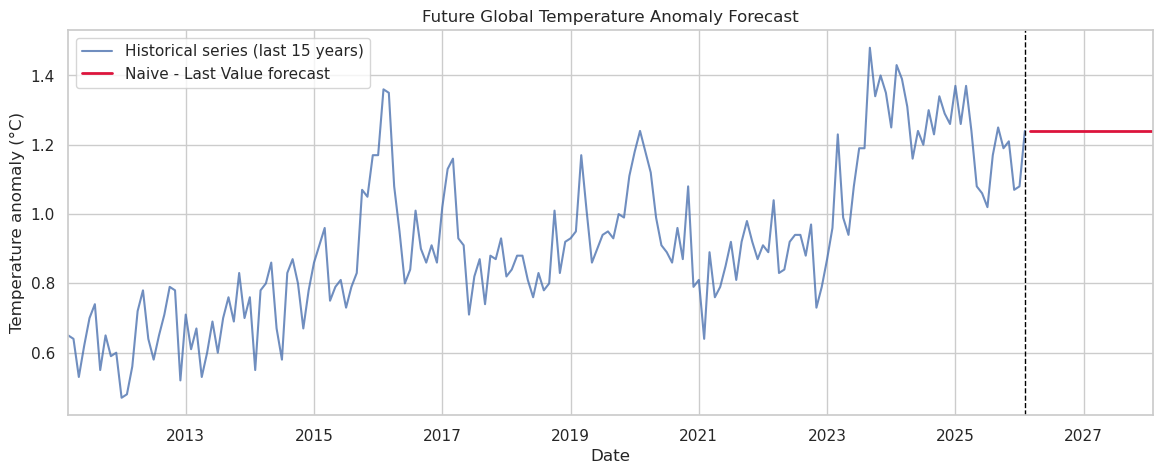

,Forecast
2026-03-31,1.24
2026-04-30,1.24
2026-05-31,1.24
2026-06-30,1.24
2026-07-31,1.24
2026-08-31,1.24
2026-09-30,1.24
2026-10-31,1.24
2026-11-30,1.24
2026-12-31,1.24


In [12]:
future_steps = 24
future_fh = np.arange(1, future_steps + 1)

if best_model_name == "Naive - Last Value":
    best_model = NaiveForecaster(strategy="last")
elif best_model_name == "Naive - Seasonal (sp=12)":
    best_model = NaiveForecaster(strategy="last", sp=12)
elif best_model_name == "ARIMA (1,1,1)":
    best_model = ARIMA(order=(1, 1, 1), suppress_warnings=True)
elif best_model_name == "Seasonal AutoARIMA":
    best_model = AutoARIMA(
        sp=12,
        seasonal=True,
        stepwise=True,
        suppress_warnings=True,
        error_action="ignore",
        max_p=3,
        max_q=3,
        max_P=2,
        max_Q=2
    )
elif best_model_name == "Exponential Smoothing":
    best_model = ExponentialSmoothing(trend="add", seasonal="add", sp=12)
else:
    try:
        best_model = AutoETS(
            auto=True,
            sp=12,
            allow_multiplicative_trend=False,
            restrict=True
        )
    except Exception:
        best_model = AutoETS(
            auto=False,
            error="add",
            trend="add",
            seasonal="add",
            damped_trend=True,
            sp=12
        )

best_model.fit(ts_data)
future_forecast = best_model.predict(future_fh)

print(f"Forecast generated for {future_steps} future months.")
print(f"Forecast range: {future_forecast.index.min().date()} to {future_forecast.index.max().date()}")

fig, ax = plt.subplots(figsize=(14, 5))
ts_data.tail(180).plot(ax=ax, label="Historical series (last 15 years)", alpha=0.8)
future_forecast.plot(ax=ax, label=f"{best_model_name} forecast", color="crimson", linewidth=2)
ax.axvline(ts_data.index.max(), color="black", linestyle="--", linewidth=1)

ax.set_title("Future Global Temperature Anomaly Forecast")
ax.set_ylabel("Temperature anomaly (°C)")
ax.legend()
plt.show()

display(future_forecast.to_frame("Forecast").head(12))